# Projet final dans le cadre de Linguistique pour la science des données  
**Auteur:** Mariette Kuzaba-Matumona



## 1 - Question  

La question, auquel je souhaite répondre avec ce projet, est la suivante: Dans quelle mesure l'analyse sémantique computationnelle des titres de presse révèle-t-elle une asymétrie dans le traitement médiatique des guerres en Iran et en Ukraine ?  

J'ai choisi de faire une comparaison de ces deux guerres, car je souhaite savoir si le ressenti, que j'ai eu en regardant et lisant les médias, apparait dans une analyse linguistique large.

## 2 - Données  

Pour répondre à cette question, je me suis concentrée sur les titres de la presse écrite en ligne dans 4 langues différentes: le français, l'anglais, l'arabe et le chinois.
J'ai utilisée BigQuery (webscrapping massif) pour accéder à la base de données du Projet GDELT qui collecte des articles de presse du monde entier quotidiennement.
J'ai récupéré dans des fichiers csv, sur une période de 3 mois environ à compter de la date de début de chacune des guerres, 250 articles de presses dans chaque langue.
Le code SQL que j'ai utilisé est disponible dans le répertoire

Les fichiers csv ont les informations suivantes pour chaque article: la date de publication, l'URL de l'article , le titre de l'article, la langue du titre et le conflit concerné.

Installation à décommenter pour que tous les packages utilisés soient bien utilisables.

In [43]:
# Installation des bibliothèques nécessaires à l'exécution du notebook si le notebook est lancé dans VSCode
# %python -m pip install --upgrade pip
# %pip install stanza sentence-transformers chromadb pandas scikit-learn matplotlib seaborn ipykernel Ipython

# Me^me chose mais pour Google Colab
# !python -m pip install --upgrade pip
# !pip install stanza sentence-transformers chromadb pandas scikit-learn matplotlib seaborn ipykernel Ipython

### 2.1 - Importation des packages

In [45]:
import pandas as pd
import stanza # Importation de Stanza pour le traitement linguistique multi-langues.
from sentence_transformers import SentenceTransformer # Pour générer les vecteurs sémantiques.
import chromadb # Importation de ChromaDB pour le stockage et la recherche vectorielle.
from sklearn.cluster import KMeans # Importation de l'algorithme K-Means pour le clustering.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Pour les calculs numériques et la gestion des tableaux.
from transformers import pipeline # Pour utiliser des modèles de deep learning pré-entraînés (Hugging Face).
from IPython.display import Image, display # Importation des modules pour l'affichage d'images

# Définition du style visuel par défaut pour tous les graphiques Seaborn.
sns.set_theme(style="whitegrid")

### 2.2 -  Extraction et préparation des données

In [46]:
df_iran = pd.read_csv("iranchara.csv")
df_iran['conflit'] = 'Iran' # Ajout d'une colonne étiquette pour identifier lee conflit dont le titre parle.

df_ukraine = pd.read_csv("ukrainechara.csv")
df_ukraine['conflit'] = 'Ukraine'

# Fusion des deux DataFrames en un seul corpus global.
df_corpus = pd.concat([df_iran, df_ukraine], ignore_index=True)
df_corpus.head(10) #Vérification du chargement.

,PublishDate,URL,Title,Langue,conflit
0,2026-02-28,https://www.el-balad.com/6863034,Israeli Defense Minister Announces Preemptive ...,Anglais,Iran
1,2026-02-28,https://local21news.com/news/nation-world/iran...,Iran's supreme leader killed in joint attack: ...,Anglais,Iran
2,2026-02-28,https://b1047.iheart.com/content/2026-02-28-us...,"US And Israel Attack Iran, With Trump Confirmi...",Anglais,Iran
3,2026-02-28,https://redstate.com/jenvanlaar/2026/02/27/bre...,UPDATED: President Trump Confirms 'Major Comba...,Anglais,Iran
4,2026-02-28,https://wdsd.iheart.com/content/2026-02-28-us-...,"US And Israel Attack Iran, With Trump Confirmi...",Anglais,Iran
5,2026-02-28,https://www.dailysignal.com/2026/02/28/breakin...,What Is Next in Iran Following US-Israel Strikes,Anglais,Iran
6,2026-03-01,https://www.9news.com.au/world/us-israel-strik...,US-Israel strikes on Iran: Luxury Dubai hotel ...,Anglais,Iran
7,2026-03-01,https://www.freemalaysiatoday.com/category/hig...,"'A terrible day', says Israel community shaken...",Anglais,Iran
8,2026-03-01,https://fox23maine.com/news/nation-world/persi...,Celebrations erupt nationwide as Persians reac...,Anglais,Iran
9,2026-03-01,https://www.firstpost.com/entertainment/elnaaz...,Elnaaz Norouzi reacts to US-Israel strikes on ...,Anglais,Iran


Mapping des langues pour correspondre aux clés utilisés par Stanza  

In [47]:
mapping_langues = {"Français": "fr", "Anglais": "en", "Arabe": "ar", "Chinois": "zh"}
df_corpus['Langue_code'] = df_corpus['Langue'].map(mapping_langues) # Remplacement des noms de langue directement dans le df.

In [48]:
# Convertit la colonne 'PublishDate' (chaîne de caractères) en objets datetime pour permettre des opérations temporelles.
df_corpus['date'] = pd.to_datetime(df_corpus['PublishDate'])

Méthode permettant d'obtenir un échantillon temporel homogène lors d'une réduction d'une nombre de titres d'articles analysés


In [49]:
# Méthode permettant d'obtenir un échantillon temporel homogène lors d'une réduction d'une nombre de titres d'articles analysés.
def echantillon_temporel_homogene(articles, n_echantillons=250):
    # Trie les articles par ordre chronologique selon la colonne 'date'.
    articles_trie = articles.sort_values('date')

    # Génère n_echantillons d'indices répartis de manière égale entre le premier (0) et le dernier indice
    # .astype(int) convertit ces positions en nombres entiers pour pouvoir s'en servir comme index.
    indices_espaces = np.linspace(0, len(articles_trie) - 1, n_echantillons).astype(int)

    # Sélectionne et renvoie l'échantillon déterminée précédemment.
    return articles_trie.iloc[indices_espaces]

Echantillonage

In [50]:
echantillons = [] # Liste temporaire pour stocker les titres échantillonés.

# Groupement par conflit et langue pour garder la répartition de 25% par chaque langue dans chaque conflit
for identifiants, sous_groupe in df_corpus.groupby(['conflit', 'Langue']):
    # Sélection de 100 articles pour garder l'exécution du notebook en-dessous
    titre = echantillon_temporel_homogene(sous_groupe, n_echantillons=100)
    echantillons.append(titre) # Ajout du sous-groupe sélectionné à la liste

# Reconstitution du DataFrame final par concaténation, mélange (sample) et remise à zéro de l'index
df_corpus = pd.concat(echantillons).sample(frac=1, random_state=42).reset_index(drop=True)

# Vérification du nombre total d'articles dans le corpus final (doit être 800)
print(f"Taille du corpus après échantillonnage : {len(df_corpus)}")

Taille du corpus après échantillonnage : 800


In [51]:
print("\n Répartition par Conflit et par Langue") # Affichage d'un titre de section
# Comptage du nombre de lignes pour chaque combinaison Conflit/Langue
repartition = df_corpus.groupby(['conflit', 'Langue_code']).size().reset_index(name="Nombre d'articles")
display(repartition) # Affichage du tableau de répartition


 Répartition par Conflit et par Langue


,conflit,Langue,Nombre d'articles
0,Iran,Anglais,100
1,Iran,Arabe,100
2,Iran,Chinois,100
3,Iran,Français,100
4,Ukraine,Anglais,100
5,Ukraine,Arabe,100
6,Ukraine,Chinois,100
7,Ukraine,Français,100



Affichage des dates limites de la période couverte par l'échantillon

In [52]:
print("\n Période couverte par l'échantillon") # Affichage d'un titre
print(f"Du : {df_corpus['date'].min().strftime('%Y-%m-%d')}") # Calcul et formatage de la date la plus ancienne
print(f"Au : {df_corpus['date'].max().strftime('%Y-%m-%d')}") # Calcul et formatage de la date la plus récente


 Période couverte par l'échantillon
Du : 2022-02-24
Au : 2026-05-27


## 3 - Analyse  

J'ai choisi de me concentrer sur les verbes d'actions


Cette partie correspond à l'analyse qui permettra de répondre à la question posée, et est principalement constituée de code propre, lisible et commenté ligne par ligne  . Les étapes analytiques comprennent le chargement des modèles linguistiques multilingues, l'extraction de rôles sémantiques et de sentiments, et un clustering automatisé  .

### 3.1 - Chargement des modèles linguistiques multilingues

Création d'un dictionnaire contenant les objets pipelines Stanza par langue  avec lemmatisation et NER

In [53]:
pipelines = {
    'fr': stanza.Pipeline('fr', processors='tokenize,mwt,pos,lemma,depparse,ner', use_gpu=False), # Pipeline français
    'en': stanza.Pipeline('en', processors='tokenize,pos,lemma,depparse,ner', use_gpu=False), # Pipeline anglais
    'ar': stanza.Pipeline('ar', processors='tokenize,mwt,pos,lemma,depparse,ner', use_gpu=False), # Pipeline arabe (inclut mwt pour les mots multi-tokens)
    'zh': stanza.Pipeline('zh-hans', processors='tokenize,pos,lemma,depparse,ner', use_gpu=False) # Pipeline chinois simplifié
}

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: fr (French):
| Processor | Package            |
----------------------------------
| tokenize  | combined           |
| mwt       | combined           |
| pos       | combined_charlm    |
| lemma     | combined_nocharlm  |
| depparse  | combined_charlm    |
| ner       | wikinergold_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| pos       | combined_charlm           |
| lemma     | combined_nocharlm         |
| depparse  | combined_charlm           |
| ner       | ontonotes-ww-multi_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: ar (Arabic):
| Processor | Package       |
-----------------------------
| tokenize  | padt          |
| mwt       | padt          |
| pos       | padt_charlm   |
| lemma     | padt_nocharlm |
| depparse  | padt_charlm   |
| ner       | aqmar_charlm  |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: zh-hans (Simplified_Chinese):
| Processor | Package          |
--------------------------------
| tokenize  | gsdsimp          |
| pos       | gsdsimp_charlm   |
| lemma     | gsdsimp_nocharlm |
| depparse  | gsdsimp_charlm   |
| ner       | ontonotes        |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


Chargement du modèle d'embeddings multilingue universel  

In [54]:
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2') #

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


La méthode ABSA (Aspect-Based Sentiment Analysis ou Analyse de Sentiment par Aspect) est une technique d'intelligence artificielle.  Elle permet d'analyser les émotions exprimées dans un texte en les liant à des éléments précis. Contrairement à une analyse de sentiment classique qui donne une note globale à un texte, l'ABSA décompose une phrase pour identifier l'aspect mentionné et le sentiment qui lui est associé. Par exemple, dans la phrase "L'écran de ce téléphone est magnifique mais la batterie est faible", elle détectera un sentiment positif pour l'aspect "écran" et un sentiment négatif pour l'aspect "batterie".

In [55]:
print("Chargement du modèle ABSA") # Information utilisateur
# Chargement d'un modèle spécifique pour l'analyse de sentiment par aspect (ABSA)
absa_pipeline = pipeline("text-classification", model="yangheng/deberta-v3-base-absa-v1.1")

Chargement du modèle ABSA


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: yangheng/deberta-v3-base-absa-v1.1
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [56]:
chroma_client = chromadb.Client() # Initialisation du client de la base de données vectorielle
try:
    chroma_client.delete_collection(name="configuration_multilingue") # Suppression de la collection si elle existe déjà
except:
    pass # Ne rien faire si la collection n'existait pas
collection_vectorielle = chroma_client.create_collection(name="configuration_multilingue") # Création de la nouvelle collection

### 3.2 - Définition des méthodes analytiques

In [57]:
def analyser_sentiment_aspect(titre, aspect):
    try:
        input_text = f"{titre} [SEP] {aspect}" # Formatage spécifique pour le modèle ABSA (Titre + Séparateur + Cible)
        result = absa_pipeline(input_text, truncation=True) # Exécution de la classification avec troncature si nécessaire
        return result[0]['label'] # Renvoie l'étiquette (Positive, Negative, Neutral)
    except:
        return "Neutral" # Valeur par défaut en cas d'erreur de traitement

In [58]:

def extraire_acteurs_et_sentiments(row):
    titre = str(row['Title']) # Extraction du titre depuis la ligne du DataFrame.
    langue = row['Langue'] # Extraction de la langue correspondante.
    nlp = pipelines.get(langue, pipelines['en']) # Sélection du pipeline Stanza approprié ou anglais par défaut si un bug se présente.
    doc = nlp(titre) # Analyse linguistique du titre par Stanza.
    acteurs_sentiments = [] # Liste pour stocker les couples acteur/sentiment.

    # Itération sur les entités nommées détectées (NER).
    for ent in doc.ents:
        if ent.type in ['GPE', 'LOC', 'ORG', 'PER']: # Filtre sur les lieux, organisations et personnes.
            aspect = ent.text # Texte de l'entité
            sentiment = analyser_sentiment_aspect(titre, aspect) # Analyse du sentiment vis-à-vis de cette entité spécifique.
            acteurs_sentiments.append(f"{aspect}: {sentiment}") # Stockage sous forme de chaîne formatée.
    return " | ".join(acteurs_sentiments) # Fusion des résultats séparés par une barre verticale.

Extraction d'un sentiment global par article

In [60]:

def extraire_sentiment_agent(texte):
    if pd.isna(texte) or texte == "": # Si l'extraction d'un sentiment sur le titre n'a pas eu lieu on le désigne comme neutre
        return "Neutre" # Changed from "Neutral" to "Neutre"
    sentiments = [part.split(": ")[-1] for part in texte.split(" | ") if ": " in part]
    if not sentiments:
        return "Neutre" # Si l'association d'un sentiment avec une entité n'a pas le bon format, on met Neutre par défaut
    # Mapping des sentiments attribués à l'agent
    if "Negative" in sentiments:
        return "Negatif"
    elif "Positive" in sentiments:
        return "Positif"
    else:
        return "Neutre"

In [59]:
def extraire_roles_multilingues(titre, code_langue):
    if code_langue not in pipelines:
        return {"Verbe_Action": None, "Agent_Brut": None, "Patient_Brut": None} # Retourne vide si langue non supportée
    nlp = pipelines[code_langue] # Récupération du moteur NLP
    doc = nlp(titre) # Analyse du titre
    resultats = [] # Liste des structures sémantiques trouvées

    for sentence in doc.sentences: # Parcours des phrases
        for word in sentence.words: # Parcours des mots
            if word.upos == "VERB": # Identification des verbes d'action
                action = word.lemma # Récupération du lemme
                agent = "Effacé/Implicite" # Valeur par défaut pour le sujet
                patient = "Inconnu" # Valeur par défaut pour l'objet

                for child in sentence.words: # Recherche des dépendances syntaxiques liées au verbe
                    if child.head == word.id:
                        if child.deprel in ['nsubj', 'obl:agent', 'nsubj:pass']:
                            agent = child.text # Attribution du sujet (agent)
                        elif child.deprel in ['obj', 'nsubj:pass'] or 'obj' in child.deprel:
                            patient = child.text # Attribution de l'objet (patient)
                resultats.append({"Verbe_Action": action, "Agent_Brut": agent, "Patient_Brut": patient})
    # Renvoie le premier verbe trouvé ou une structure vide
    return resultats[0] if resultats else {"Verbe_Action": None, "Agent_Brut": None, "Patient_Brut": None}

### 3.3 - Exécution de l'analyse

Application de l'extraction des NER et du sentiment associé à l'agent sur chaque ligne du corpus

In [62]:
print("Analyse ABSA en cours")
df_corpus['Aspects_Sentiments'] = df_corpus.apply(extraire_acteurs_et_sentiments, axis=1)
df_corpus.head()

Analyse ABSA en cours


,PublishDate,URL,Title,Langue,conflit,Langue_code,date,Aspects_Sentiments
0,2022-05-19,https://www.voachinese.com/a/interview-with-xu...,专访许成钢(3): 谈俄乌战争与中国防疫人民战争的关键性相似,Chinois,Ukraine,zh,2022-05-19,
1,2022-04-19,https://news.ltn.com.tw/news/world/breakingnew...,網瘋傳手機擋住俄軍子彈！烏克蘭士兵撿回一命 廠牌型號曝光 - 國際,Chinois,Ukraine,zh,2022-04-19,
2,2026-04-13,https://www.capitalgazette.com/2026/04/13/trum...,US short 10 million houses. White House lays o...,Anglais,Iran,en,2026-04-13,US: Neutral | White House: Neutral
3,2022-03-13,https://arabic.euronews.com/2022/03/12/venezue...,"فنزويلا تعرب عن استعدادها لإجراء ""حوار"" مع أور...",Arabe,Ukraine,ar,2022-03-13,
4,2026-04-15,https://economictimes.indiatimes.com/news/inte...,US says nine vessels turned back in 48 hours o...,Anglais,Iran,en,2026-04-15,US: Neutral | Iran: Neutral


Application de l'extraction des rôles sémantiques  


In [63]:
print("Extraction des rôles sémantiques en cours")
# Application de l'analyse syntaxique (Verbe/Sujet/Objet) sur chaque titre
analyses = df_corpus.apply(lambda row: extraire_roles_multilingues(row['Title'], row['Langue_code']), axis=1)
df_elements = pd.json_normalize(analyses) # Transformation de la liste de dictionnaires en colonnes de DataFrame

Extraction des rôles sémantiques en cours


Fusion avec le csv initial et suppression des valeurs nulles pour le verbe d'action  

In [64]:
df_final = pd.concat([df_corpus, df_elements], axis=1) # Fusion des données initiales avec les rôles sémantiques.
df_final = df_final.dropna(subset=['Verbe_Action']) # Suppression des lignes où aucun verbe n'a été détecté.

Liste de tous les lemmes de verbes à travers les langues  

In [65]:
verbes_uniques = df_final['Verbe_Action'].unique().tolist() # Extraction de la liste des lemmes de verbes sans doublons.

Calcul des vecteurs de chaque verbe dans un espace multilingue crée par le modèle paraphrase-multilingual-MiniLM-L12-v2

In [66]:
vecteurs = embedder.encode(verbes_uniques).tolist() # Conversion de chaque verbe unique en vecteur numérique multilingue.

In [67]:
collection_vectorielle.add(
    embeddings=vecteurs, # Enregistrement des coordonnées vectorielles
    documents=verbes_uniques, # Texte associé (le verbe)
    ids=[f"v_{i}" for i in range(len(verbes_uniques))] # Génération d'identifiants uniques v_0, v_1, etc.
)

### 3.4 - Création des Clusters

In [84]:
NOMBRE_CLUSTERS = 5 # Nombre de groupes de verbes souhaités.
kmeans = KMeans(n_clusters=NOMBRE_CLUSTERS, random_state=42) # Initialisation de l'algorithme avec une graine fixe.
kmeans.fit(vecteurs) # Calcul des centroïdes et affectation des verbes aux clusters.

KMeans(n_clusters=5, random_state=42)

In [85]:
# Création d'un dictionnaire Verbe -> Numéro de Cluster.
verbe_vers_cluster = {verbes_uniques[i]: kmeans.labels_[i] for i in range(len(verbes_uniques))}

# Association du numéro de cluster à chaque ligne de notre DataFrame final.
df_final['Cluster_ID'] = df_final['Verbe_Action'].map(verbe_vers_cluster)

Affichage des 40 premiers verbes du cluster pour me permettre de les analyser

In [86]:
clusters = [] # Liste pour mémoriser le contenu textuel des clusters.

for i in range(NOMBRE_CLUSTERS):
    # Filtrage des verbes appartenant au cluster i.
    mots_du_cluster = [v for v, c in verbe_vers_cluster.items() if c == i]
    clusters.append(mots_du_cluster)
    print(f"\n CLUSTER SÉMANTIQUE {i} ")
    print(", ".join(mots_du_cluster[:40]))


 CLUSTER SÉMANTIQUE 0 
mean

 CLUSTER SÉMANTIQUE 1 
擋, lay, أَعرَب, say, 援, répéter, describe, 同意, 领导, launch, réunir, 露出, naître, عَلَّق, 布查, اِنتَهَى, 抱, révéler, cross, 讓, 匿名, 用, حَذَّر, doper, spote, 罹癌, peser, وَاج, دَرَس, chute, أَطَال, اِنتَقَد, get, 拍, أَثَار, 發展, 稱, demander, batter, vivre

 CLUSTER SÉMANTIQUE 2 
charge

 CLUSTER SÉMANTIQUE 3 
ignorer, accuser, 战斗, attaquer, concerner, 警告, évacuer, damage, 嚇, 捍衛, warn, menacer, 戰, kill, 入侵, avoid, hit, 怕爆, claim, fear, 自卫, condemn, accuse, intercepter, strike, 預防, watch, bombarder, 制裁, cause, block, injure, ban, 獨裁, suspendre, condamner, exploit, 摧毁, oppose, denounce

 CLUSTER SÉMANTIQUE 4 
hold


Calcul du sentiment associé à l'agent pour chaque article

In [87]:
df_final['Main_Sentiment'] = df_final['Aspects_Sentiments'].apply(extraire_sentiment_principal)

### 3.5 - Visualisation graphique

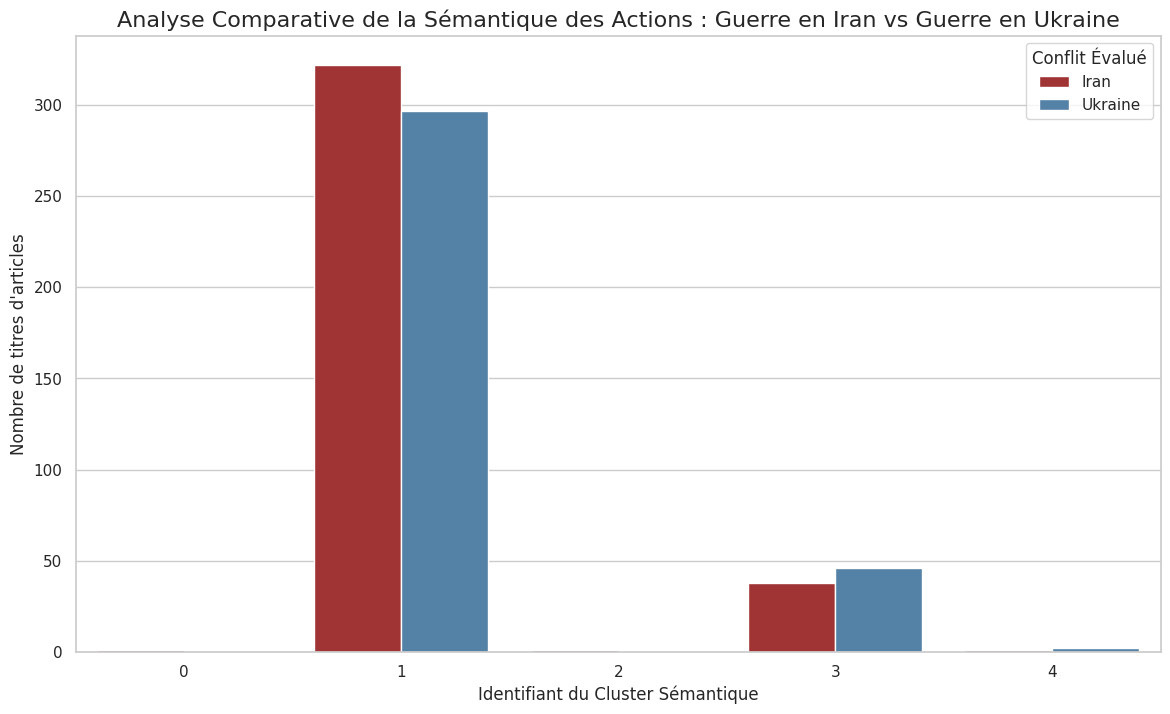

In [88]:
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df_final,
    x='Cluster_ID', #numéro du cluster
    hue='conflit',
    palette={"Iran": "#b22222", "Ukraine": "#4682b4"} )

plt.title("Analyse Comparative de la Sémantique des Actions : Guerre en Iran vs Guerre en Ukraine", fontsize=16) # Titre principal
plt.xlabel("Identifiant du Cluster Sémantique", fontsize=12)
plt.ylabel("Nombre de titres d'articles", fontsize=12)
plt.legend(title="Conflit Évalué")
plt.show()

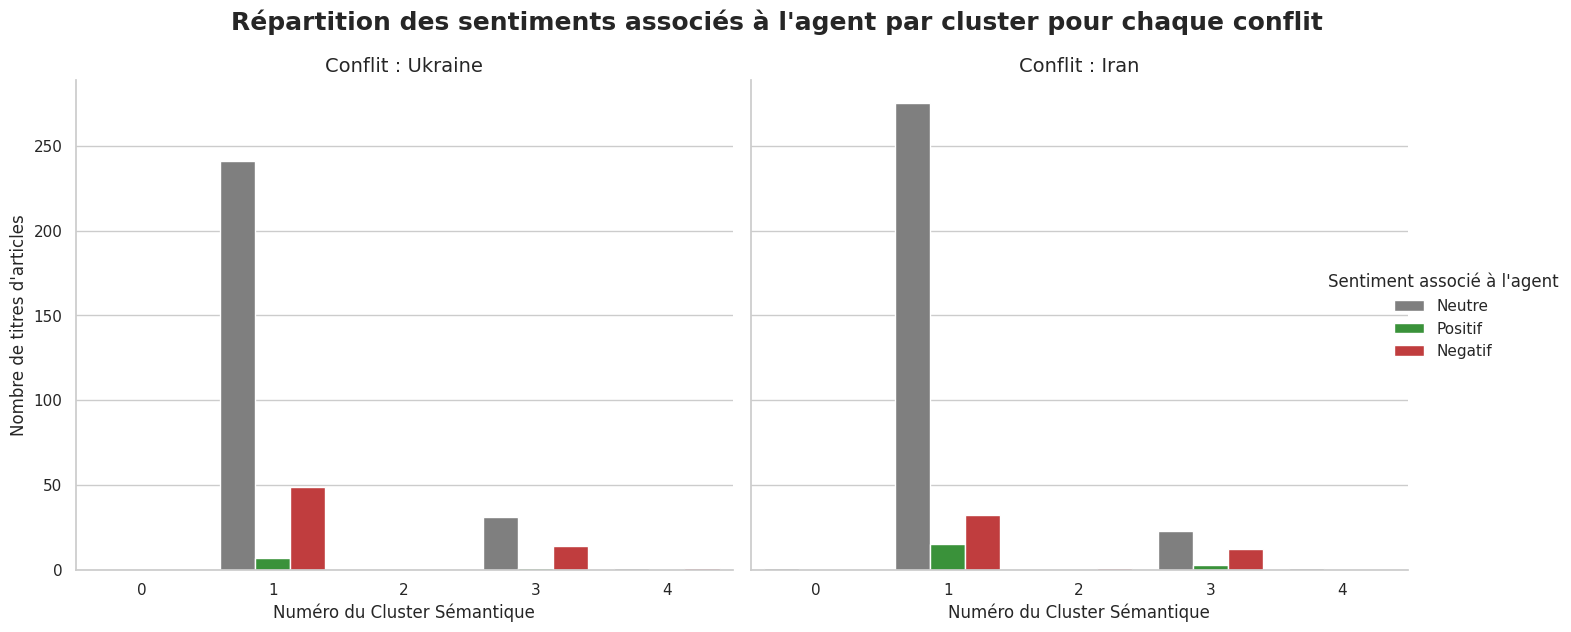

In [89]:
g = sns.catplot(
    data=df_final,
    kind="count",
    x="Cluster_ID",
    hue="Main_Sentiment",
    col="conflit", # Création de deux sous-graphes pour chaque conflit.
    palette={"Positif": "#2ca02c", "Negatif": "#d62728", "Neutre": "#7f7f7f"},
    height=6,
    aspect=1.2,
    legend_out=True # Place la légende à l'extérieur des graphiques
)

# Configuration des labels et titres des axes
g.set_axis_labels("Numéro du Cluster Sémantique", "Nombre de titres d'articles")
g.set_titles("Conflit : {col_name}", size=14)
g.legend.set_title("Sentiment associé à l'agent")

# Centrage du titre principale.
plt.suptitle("Répartition des sentiments associés à l'agent par cluster pour chaque conflit", y=1.05, fontsize=18, fontweight='bold')

plt.show()

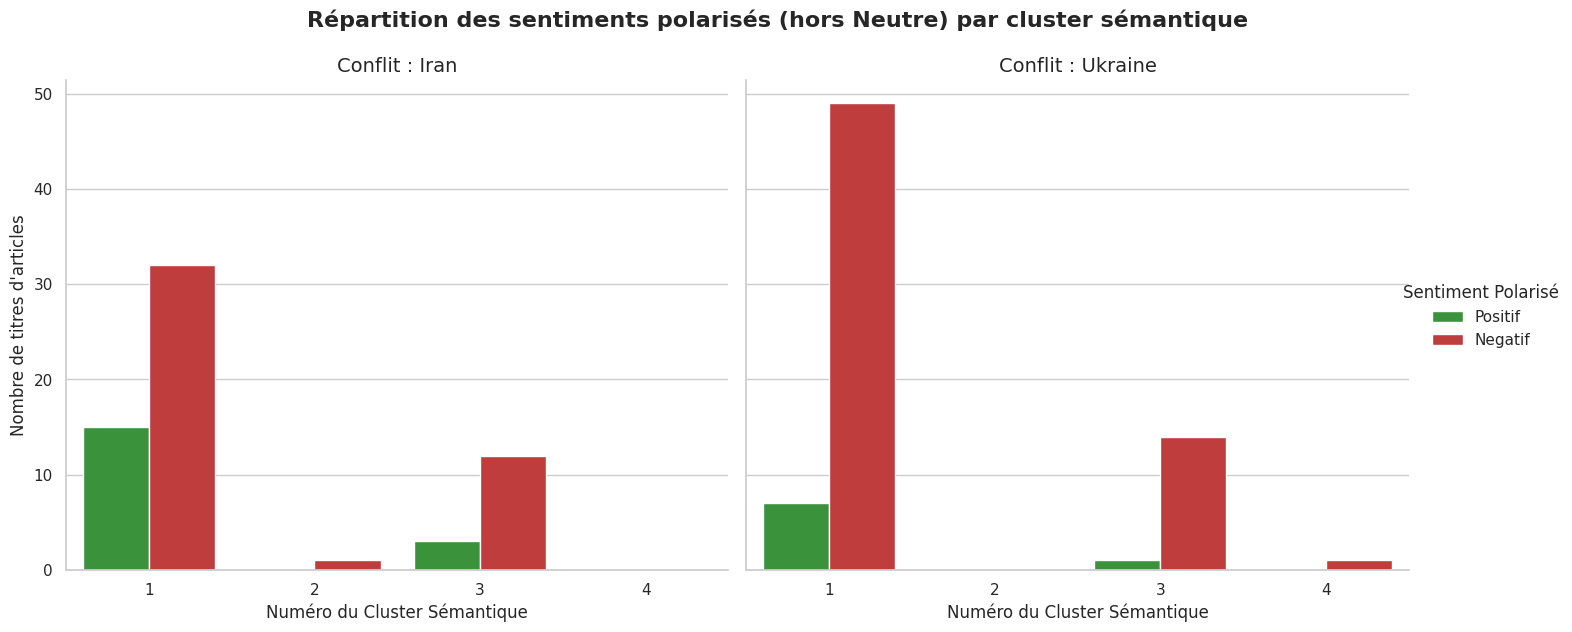

In [90]:
# Création d'un nouveau DataFrame excluant les articles dont le sentiment est 'Neutre' pour
# permettre une meilleure visualisation
df_sans_neutre = df_final[df_final['Main_Sentiment'] != 'Neutre']

g2 = sns.catplot(
    data=df_sans_neutre,
    kind="count",
    x="Cluster_ID",
    hue="Main_Sentiment",
    col="conflit",
    palette={"Positif": "#2ca02c", "Negatif": "#d62728"},
    height=6,
    aspect=1.2,
    legend_out=True
)


g2.set_axis_labels("Numéro du Cluster Sémantique", "Nombre de titres d'articles")
g2.set_titles("Conflit : {col_name}", size=14)
g2.legend.set_title("Sentiment Polarisé")

# Ajout et centrage d'un titre principal pour la figure
plt.suptitle("Répartition des sentiments polarisés (hors Neutre) par cluster sémantique", y=1.05, fontsize=16, fontweight='bold')

plt.show()

## 4. Conclusion

En observant les 40 premiers clusters, j'ai assigné à chaque cluster une étiquettes qui sont les suivantes:
- le Cluster 0 ne contient que "mean" donc je
- le Cluster 1 contient des verbes qui rappelle les communications et les dynamiques de mouvement
- le Cluster 2 ne contient que "charge"
- le Cluster 3 qui contient des verbes sur l'aggressivité et donc les attaques sur le terrain et dans les communications
- le Cluster 4 contient juste hold

Dans ces clusters, on n'observe pas d'asymétrie dans le type d'action attribué à chacun des deux pays dans les titres.

Cependant quand on effectue une analyse des sentiments associés à ces types d'actions une asymétrie dans le cluster 1 apparaît avec plus d'articles pour la guerre en Ukraine qui associe ce type d'action au négatif. Mon interprétation est que cela est problabement dû à la position géographiqe de l'Ukraine. L'Europe n'ayant pas eu de guerres totales sur son territoire depuis les années 90.
Tandis que le nombre d'articles plus positifs pour l'Iran dans ce cluster sont problabement dû aux négotiations plus fréquentes entre les bélligérents.

Pour le Cluster 3, une asymétrie ne se dégage pas.

Pour conclure, l'analyse sémantique de titres de presse permet de dégager une asymétrie quand on prend en compte les sentiments associés aux verbes d'actions attribués à chaque agent.




Une des limites de ce projet est le nombre, plus important proportionnellement, que les titres en anglais, de titres en arabe et en chinois auxquelles le modèle ABSA que j'ai utilisé n'a pas associé de sentiments. cela fait disparaître l'aspect plus global des observations sur la façon dont les deux pays sont montrés dans les médias.

Une des limites de ce projet est le nombre, plus important proportionnellement que les titres en anglais, de titres en arabe et en chinois auxquelles le modèle ABSA, que j'ai utilisé, n'associe pas de sentiments. Egalement l'échantillonnage pour garder une exécution en-dessous d'1h fait probablement disparaître des clusters possibles.


Egalement si on observe la version du graphique des sentiments que j'ai obtenu en utilisant tous les articles de chaque langue. On observe clairement des clusters ayant plus de verbe. Ce qui permettrait peut-être de dégager un sens meilleure des clusters crées et donc une meilleure idée de l'asymétrie de représentation entre les deux conflits

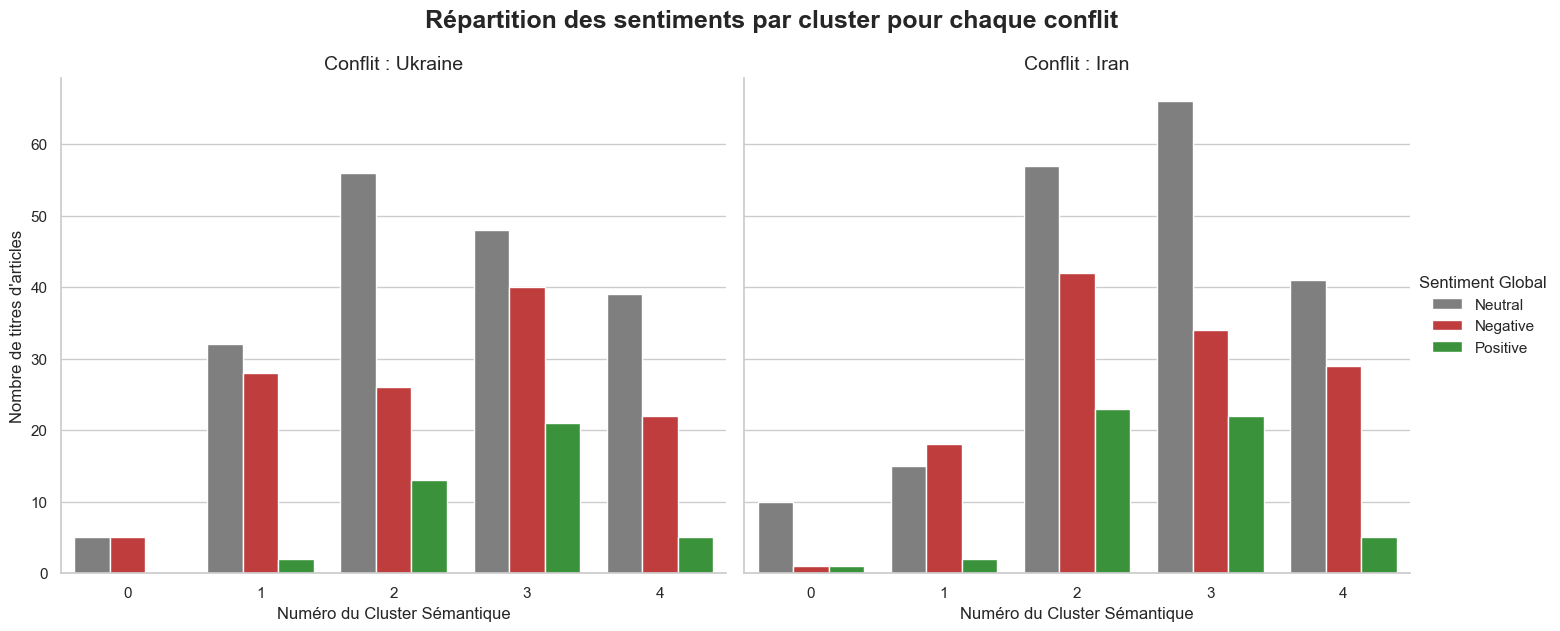

In [91]:
# Chargement et affichage du fichier image 'senti.png'
display(Image(filename='senti.png'))